# Multivariate Forward Selection guiado por complejidad

En este notebook vamos a analizar los resultados que obtenemos cuando hacemos un forward selection con cada una de las medidas de complejidad de estudio (Hostility, kDN, N1). Los pasos que hemos seguido son:
- Estudiamos la complejidad univariante con cada feature.
- Establecemos un ranking en base a dichos valores univariantes.
- En función del ranking logrado cada medida de complejidad, vamos metiendo variables de una en una y evaluando la complejidad.
- Hacemos un gráfico que muestre cómo va cambiando la complejidad según aumenta el número de variables. La idea es observar un codo (como en el knee plot de las k-means) que indique que ya no merece la pena seguir añadiendo variables debido a la escasa reducción de la complejidad.

In [1]:
import copy
from sklearn import preprocessing
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from skrebate import ReliefF
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import glob
import re
# from UnivariateInstanceComplexityAnalysis_Code import *
# from All_measures import *
from ForwardComplexity_UnivariateRanking import *
from PerformanceClassifiers_Forward import *

In [2]:
import os
os.chdir("..")
root_path = os.getcwd()

In [3]:
# csv_file = "Results_ForwardComplexity/ArtificialDataset16_forward_dataset_classes.csv"
# df_forward = load_forward_selection_results(csv_file)
# plot_forward_complexity(df_forward, dataset_name="ArtificialDataset16")

In [4]:
# Vamos haciendo esto porque como la ejecución tarda mucho, no tenemos los resultados ejecutados para todos los casos y puede generar gráficos erróneos
files_synthetic = ['Synthetic_Metadata/ArtificialDataset1_features.csv',
 'Synthetic_Metadata/ArtificialDataset2_features.csv',
 'Synthetic_Metadata/ArtificialDataset3_features.csv',
 'Synthetic_Metadata/ArtificialDataset4_features.csv',
 'Synthetic_Metadata/ArtificialDataset5_features.csv',
 'Synthetic_Metadata/ArtificialDataset6_features.csv',
 'Synthetic_Metadata/ArtificialDataset7_features.csv',
 'Synthetic_Metadata/ArtificialDataset8_features.csv',
 'Synthetic_Metadata/ArtificialDataset9_features.csv',
 'Synthetic_Metadata/ArtificialDataset10_features.csv',
 'Synthetic_Metadata/ArtificialDataset11_features.csv',
 'Synthetic_Metadata/ArtificialDataset12_features.csv',
 'Synthetic_Metadata/ArtificialDataset13_features.csv',
 'Synthetic_Metadata/ArtificialDataset14_features.csv',
 'Synthetic_Metadata/ArtificialDataset15_features.csv',
 'Synthetic_Metadata/ArtificialDataset16_features.csv',
 'Synthetic_Metadata/ArtificialDataset17_features.csv',
 'Synthetic_Metadata/ArtificialDataset18_features.csv',
 'Synthetic_Metadata/ArtificialDataset19_features.csv',
 'Synthetic_Metadata/ArtificialDataset20_features.csv',
 'Synthetic_Metadata/ArtificialDataset21_features.csv',
 'Synthetic_Metadata/ArtificialDataset22_features.csv']

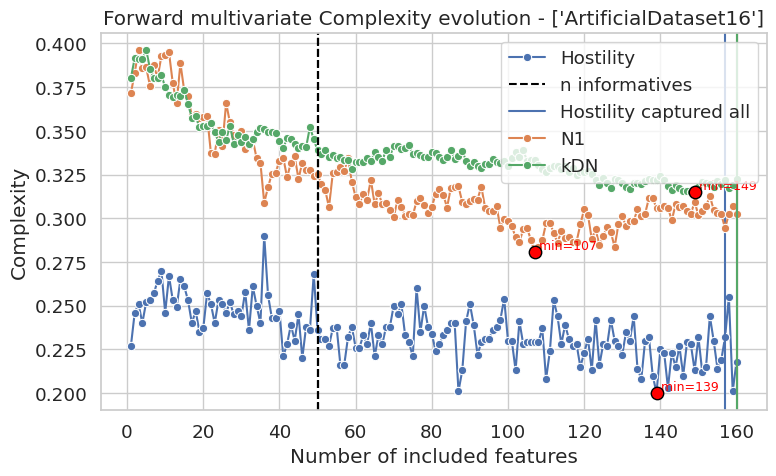

In [5]:
# Leer todos los comparison.csv de la carpeta
files = glob.glob("Results_ForwardComplexity/*_forward_dataset_classes.csv")
files = sorted(files,key=lambda f: int(re.search(r"ArtificialDataset(\d+)_", f).group(1)))
# files_synthetic = glob.glob("Synthetic_Metadata/*_features.csv")
# files_synthetic = sorted(files_synthetic,key=lambda f: int(re.search(r"ArtificialDataset(\d+)_", f).group(1)))
figsize = (8,5)
for f, fs in zip(files[:16],files_synthetic[:16]):
    df_forward = load_forward_selection_results(f)
    dataset_name = [re.search(r"/([^/_]+)_", f).group(1)]
    _, captured_info_df = analyze_informative_capture(forward_csv_path=f,metadata_csv_path=fs)
    plot_forward_complexity(df_forward, dataset_name=dataset_name,figsize=figsize, captured_info_df=captured_info_df)

# _, captured_info_df = analyze_informative_capture(
#     forward_csv_path="Results_ForwardComplexity/ArtificialDataset1_forward_dataset_classes.csv",
#     metadata_csv_path="Synthetic_Metadata/ArtificialDataset1_features.csv")
#
#
# csv_file = "Results_ForwardComplexity/ArtificialDataset1_forward_dataset_classes.csv"
# df_forward = load_forward_selection_results(csv_file)
# figsize = (8,5)
# plot_forward_complexity(df_forward, dataset_name="ArtificialDataset1",figsize=figsize, captured_info_df=captured_info_df)



En estos gráficos, la línea discontinua negra representa el número real de variables informativas. Las líneas continuas de colores (una referente a cada medida de complejidad) indica en qué momento el ranking formado por cada una de las medidas de complejidad ya incluye a todas las variables informativas. ¡OJO! Que esta información hay que cogerla un poco con pinzas porque como hay variables redundantes y ruidosas, lo importante realmente es no pillar ni ruidosas ni redundantes, pero si x1=x2+x3, cualquier subconjunto de 2 de esas variables me sirve como informativa y "por definición" las únicas informativas serán la x1 y la x2 (porque las primeras son las informativas).

De modo que la manera correcta de hacer esto sería analizar qué subconjunto de variables elige cada método y qué calidad y redundancia tienen dichas variables.

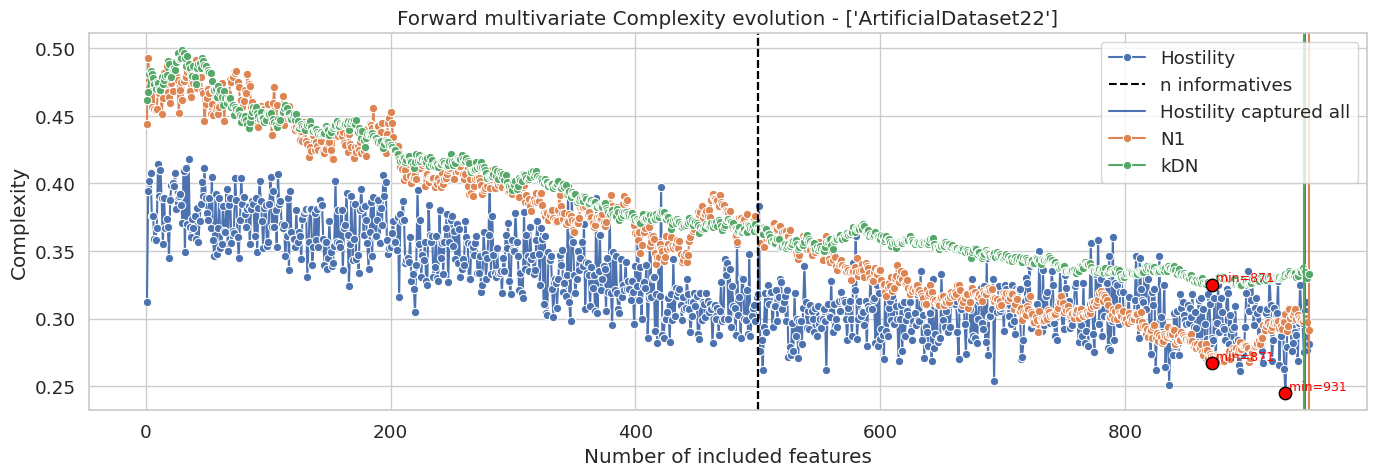

In [6]:
figsize = (14,5)
for f, fs in zip(files[16:],files_synthetic[16:]):
    df_forward = load_forward_selection_results(f)
    dataset_name = [re.search(r"/([^/_]+)_", f).group(1)]
    _, captured_info_df = analyze_informative_capture(forward_csv_path=f,metadata_csv_path=fs)
    plot_forward_complexity(df_forward, dataset_name=dataset_name,figsize=figsize, captured_info_df=captured_info_df)


En general sí que se aprecia tendencia decreciente y se puede localizar un codo. Es más fácil de identificar en los conjuntos con pocas variables porque salen menos puntitos en el gráfico. También ees más difícil observarlos cuando los datasets son muy complejos (solapamiento, lío de clases, imbalanced, etc.).

También observo que en los datasets con muchas variables, aunque sean sencillos, simplemente se aprecia una tendencia lineal decreciente sin patrón particular. Es decir, cuesta más encontrar el codo o ese corte de variables. Creo que puede ser porque esos datasets realmente no tengan mucha lógica, es decir, un dataset en el que sean necesarias/informativas 300 variables? En las cosas que veo del estado del arte, eel subconjunto final de variables suele ser menor. --> HACER EXPERIMENTO DE REDUCIR NÚMERO DE VARIABLES PARA VER RENDIMIENTO DE MODELOS EN ESTOS CASOS (ESTO YA DEBERÍAMOS VERLO EN LOS RESULTADOS DE CLASIFICACIÓN DEL FORWARD).
Puede suceder también que, a mayor número de variables, estemos entrando un poco en la problemática de the curse of dimensionality y eso haga que los resultados (descenso de complejidad) sea poco informativa. Otra opción nada descartable es que estén ocurriendo estos problemas a la vez.

### Evolución del rendimiento d los modelos siguiendo la selección de variables forward

In [7]:
# Leer todos los comparison.csv de la carpeta
files_cl = glob.glob("Results_ForwardComplexity/*_forward_summary_fullclassification.csv")
files_cl = sorted(files_cl,key=lambda f: int(re.search(r"ArtificialDataset(\d+)_", f).group(1)))


In [8]:
files =['Results_ForwardComplexity/ArtificialDataset1_forward_dataset_classes.csv',
 'Results_ForwardComplexity/ArtificialDataset2_forward_dataset_classes.csv',
 'Results_ForwardComplexity/ArtificialDataset3_forward_dataset_classes.csv',
 'Results_ForwardComplexity/ArtificialDataset4_forward_dataset_classes.csv',
 'Results_ForwardComplexity/ArtificialDataset5_forward_dataset_classes.csv',
 'Results_ForwardComplexity/ArtificialDataset6_forward_dataset_classes.csv',
 'Results_ForwardComplexity/ArtificialDataset7_forward_dataset_classes.csv',
 'Results_ForwardComplexity/ArtificialDataset8_forward_dataset_classes.csv',
 'Results_ForwardComplexity/ArtificialDataset9_forward_dataset_classes.csv',
 'Results_ForwardComplexity/ArtificialDataset10_forward_dataset_classes.csv',
 'Results_ForwardComplexity/ArtificialDataset11_forward_dataset_classes.csv',
 'Results_ForwardComplexity/ArtificialDataset12_forward_dataset_classes.csv',
 'Results_ForwardComplexity/ArtificialDataset13_forward_dataset_classes.csv',
 'Results_ForwardComplexity/ArtificialDataset14_forward_dataset_classes.csv',
 'Results_ForwardComplexity/ArtificialDataset15_forward_dataset_classes.csv',
 'Results_ForwardComplexity/ArtificialDataset16_forward_dataset_classes.csv',
 'Results_ForwardComplexity/ArtificialDataset18_forward_dataset_classes.csv',
 'Results_ForwardComplexity/ArtificialDataset19_forward_dataset_classes.csv',
 'Results_ForwardComplexity/ArtificialDataset20_forward_dataset_classes.csv']

In [9]:
files_synthetic = ['Synthetic_Metadata/ArtificialDataset1_features.csv',
 'Synthetic_Metadata/ArtificialDataset2_features.csv',
 'Synthetic_Metadata/ArtificialDataset3_features.csv',
 'Synthetic_Metadata/ArtificialDataset4_features.csv',
 'Synthetic_Metadata/ArtificialDataset5_features.csv',
 'Synthetic_Metadata/ArtificialDataset6_features.csv',
 'Synthetic_Metadata/ArtificialDataset7_features.csv',
 'Synthetic_Metadata/ArtificialDataset8_features.csv',
 'Synthetic_Metadata/ArtificialDataset9_features.csv',
 'Synthetic_Metadata/ArtificialDataset10_features.csv',
 'Synthetic_Metadata/ArtificialDataset11_features.csv',
 'Synthetic_Metadata/ArtificialDataset12_features.csv',
 'Synthetic_Metadata/ArtificialDataset13_features.csv',
 'Synthetic_Metadata/ArtificialDataset14_features.csv',
 'Synthetic_Metadata/ArtificialDataset15_features.csv',
 'Synthetic_Metadata/ArtificialDataset16_features.csv',
 'Synthetic_Metadata/ArtificialDataset18_features.csv',
 'Synthetic_Metadata/ArtificialDataset19_features.csv',
 'Synthetic_Metadata/ArtificialDataset20_features.csv']

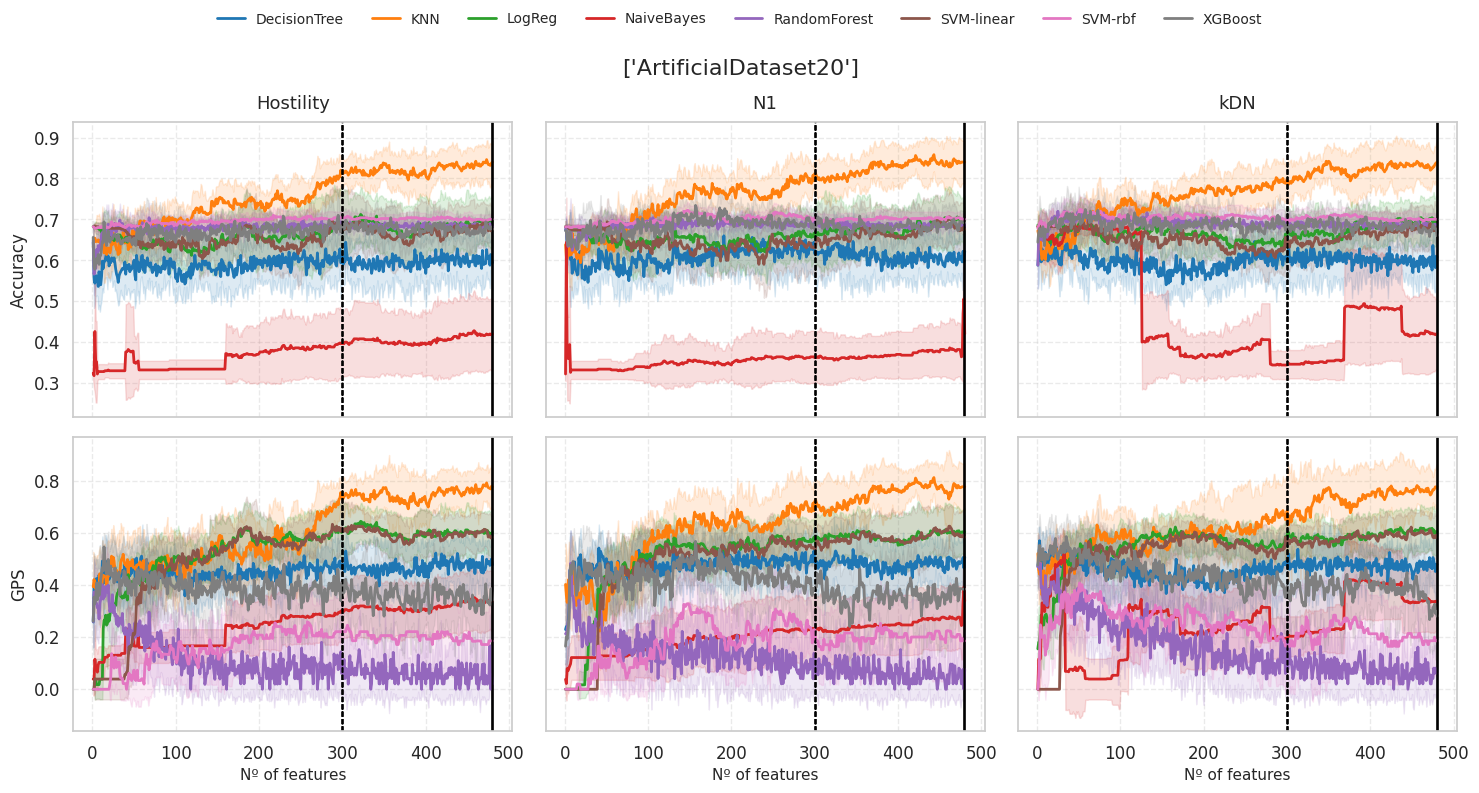

In [10]:
for f, fs, fc  in zip(files,files_synthetic,files_cl):
    summary_df = pd.read_csv(fc)
    dataset_name = [re.search(r"/([^/_]+)_", fc).group(1)]
    _, captured_info_df = analyze_informative_capture(forward_csv_path=f,metadata_csv_path=fs)
    plot_dataset_performance_grid(summary_df,dataset_name=dataset_name,captured_info_df = captured_info_df,
                                  measures=["Hostility", "N1", "kDN"],
    metrics=[("mean_acc", "Accuracy"), ("mean_gps", "GPS")],show_std=True)




Esto es más notable en conjuntos de datos sencillos (poco complejos) que parece que es más relevante el número de variables que pillar un buen subconjunto porque  se ve que, inclusive con menos variables (en numéro) de las realmente informativas se pueden alcanzar rendimientos igual de buenos. Véase como ejemplo los datasets: 5, 6 y 7.

Cuando empieza a haber más variables y el conjunto de datos es más complejo, ya sí es más necesario alcanzar el número debido de variables. Los gráficos se ven bastante más caóticos.

## Evolución performance clasificadores

Graficamos cómo va cambiando la performance (con accuracy y gps) de los clasificadores (solo SVM rbf y knn por gasto computacional) según vamos añadiendo de 1 en 1 las variables. Comenzamos añadiendo todas las informativas y luego el resto en orden aleatorio. Esto lo hacemos porque en los gráficos de performance previo (metiendo variables en el orden que indican las medidas de complejidad) hemos visto que a veces ya están incluidas todas las variables informativas y aun así el rendimiento sigue creciendo. Es decir, las variables no redudantes o ruidosas ayudan a mejorar, en algún caso, el rendimiento de los clasificadores.

In [11]:
files_synthetic = ['Synthetic_Metadata/ArtificialDataset2_features.csv',
 'Synthetic_Metadata/ArtificialDataset3_features.csv',
 'Synthetic_Metadata/ArtificialDataset7_features.csv',
 'Synthetic_Metadata/ArtificialDataset8_features.csv',
 'Synthetic_Metadata/ArtificialDataset10_features.csv',
 'Synthetic_Metadata/ArtificialDataset11_features.csv',
 'Synthetic_Metadata/ArtificialDataset12_features.csv',
 'Synthetic_Metadata/ArtificialDataset14_features.csv',
 'Synthetic_Metadata/ArtificialDataset16_features.csv',
 'Synthetic_Metadata/ArtificialDataset17_features.csv',
 'Synthetic_Metadata/ArtificialDataset18_features.csv',
 'Synthetic_Metadata/ArtificialDataset19_features.csv',
 'Synthetic_Metadata/ArtificialDataset20_features.csv',
 'Synthetic_Metadata/ArtificialDataset21_features.csv']


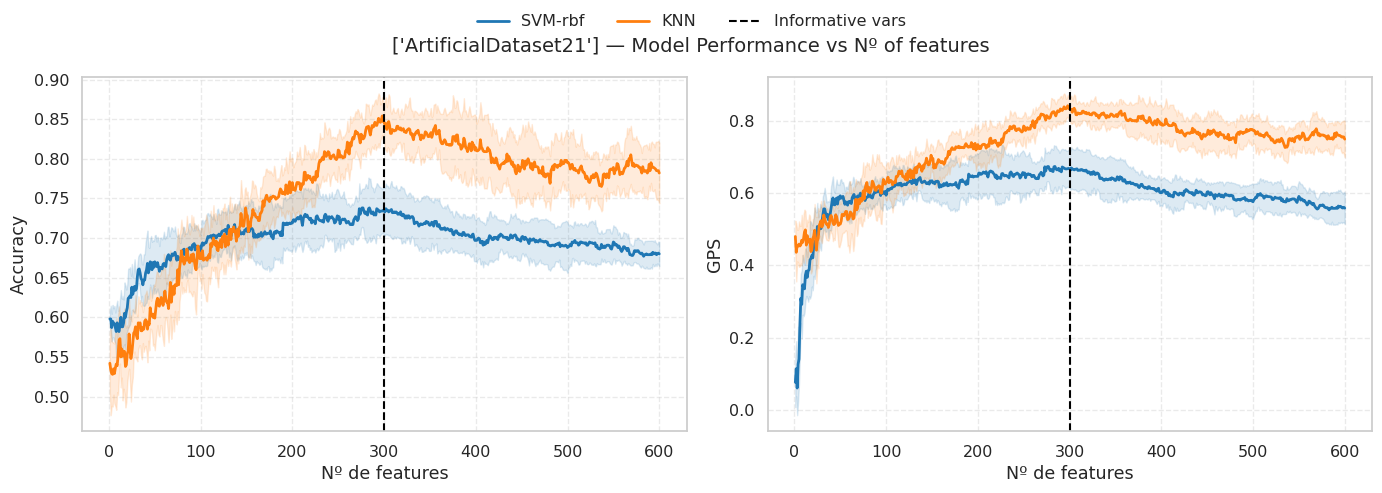

In [12]:
# Leer todos los comparison.csv de la carpeta
files_cl = glob.glob("Results_PerformanceClassifiers_Forward/*_informative_order_summary.csv")
files_cl = sorted(files_cl,key=lambda f: int(re.search(r"ArtificialDataset(\d+)_", f).group(1)))
# files_synthetic = glob.glob("Synthetic_Metadata/*_features.csv")
# files_synthetic = sorted(files_synthetic,key=lambda f: int(re.search(r"ArtificialDataset(\d+)_", f).group(1)))

for f_cl, fs in zip(files_cl,files_synthetic):
    feature_info = pd.read_csv(fs)
    dataset_name = [re.search(r"/([^/_]+)_", fs).group(1)]
    summary_df= pd.read_csv(f_cl)
    n_informative = len(feature_info[feature_info.feature_type == 'informative'])
    plot_models_two_panel_performance(summary_df,dataset_name=dataset_name,n_informative=n_informative,
    figsize=(14,5),show_std=True)


En general se ve perfectamente el corte de las variables informativas pero cuando hay más variables o el conjunto es más difícil, se ve claramente que con menos variables se alcanzaría un rendimiento similar. Así, concluimos que no es tan interesante estudiar esa evolución de rendimieento/complejidad en función de las variables que voy metiendo, es más quién gana en el juego de "quién encuentra el menor subconjunto de variables que ofrezca el mayor rendimiento". Pero no estamos haciendo el análisis real de qué variables son realmente las buenas que explican (de cara por ejemplo a XML), lo que estamos haciendo es seleccionar cuáles son las buenas para predecir.

En todo esto podríamos continuar haciendo un backward o un stepwise (nótese que en este forward lo único nuevo que podíamos conseguir era seleccionar el número adecuado de variables en base al codo del gráfico pero que las variables que íbamos a elegir estaban determinadas por el ranking univariante de la complejidad y ya vimos que eso no funcionaba bien). Pero por tema de gasto computacional y en vistas del estado del arte, vamos a enfocarnos más en la versión distribuida.

## Comparación: cuándo pilla cada método todas las informativas?

OJO! Esto es un poco tricky porque hay otras variables, consideradas redudantes, que son combinación de las informativas. Entonces otra solución válida sería no contener variables redundantes en el sentido de que si x1=x2+x3 pues solo necesito 2 de esas 3 y, en principio, cualquier combinación de 2 de esas 3 es buena. Sin embargo, nosotros estamos contando cuándo se pillan las que se definen originalmente como informativas. TAMPOCO SALIMOS BIEN

In [13]:
def combine_captured_tables(captured_info_filters, captured_info_forward):
    """
    Combina la información de los métodos tipo filtro (SOTA)
    con los de complejidad (forward selection).
    """
    df_filt = captured_info_filters.copy()
    df_filt["type"] = "Filter (SOTA)"
    df_filt.rename(columns={"method": "method_name"}, inplace=True)

    df_fwd = captured_info_forward.copy()
    df_fwd["type"] = "Complexity-based"
    df_fwd.rename(columns={"measure": "method_name","subset_all_informative_included":'captured_k'}, inplace=True)

    combined = pd.concat([df_filt, df_fwd], ignore_index=True)
    combined = combined[["type", "method_name", "n_informative", "captured_k"]]

    return combined.sort_values(["type", "method_name"])


In [14]:
# Dataset 2
dataset_name = 'ArtificialDataset2'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=1000,n_informative=10,n_noise=2,
                                         n_redundant_linear=4,n_redundant_nonlinear=2,
                                    flip_y=0, class_sep = 0.6, n_clusters_per_class=1 , weights=[0.5],
                                                     random_state=0,noise_std=0.01)

_, captured_info_df = analyze_informative_capture(forward_csv_path='Results_ForwardComplexity/ArtificialDataset2_forward_dataset_classes.csv',metadata_csv_path='Synthetic_Metadata/ArtificialDataset2_features.csv')


feature_info = pd.read_csv("Synthetic_Metadata/ArtificialDataset2_features.csv")
captured_filter = capture_informatives_by_filters(X, y, feature_info, methods=None, random_state=0)

comparison_table = combine_captured_tables(captured_filter, captured_info_df)

print('--------------- Dataset 2 ------------------')
display(comparison_table.style.format({"captured_k": "{:.0f}"}).background_gradient(subset=["captured_k"], cmap="Blues"))

,type,method_name,n_informative,captured_k
5,Complexity-based,nan,10,18
6,Complexity-based,nan,10,17
7,Complexity-based,nan,10,17
1,Filter (SOTA),f_classif,10,18
0,Filter (SOTA),mutual_info,10,17
3,Filter (SOTA),relief,10,16
2,Filter (SOTA),rf,10,16
4,Filter (SOTA),xgb,10,18


In [15]:
### Dataset 3
dataset_name = 'ArtificialDataset3'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=1000,n_informative=25,n_noise=5,
                                         n_redundant_linear=7,n_redundant_nonlinear=8,
                                         flip_y=0, class_sep=1, n_clusters_per_class=1, weights=[0.5],
                                                     random_state=0,noise_std=0.05)

_, captured_info_df = analyze_informative_capture(forward_csv_path='Results_ForwardComplexity/ArtificialDataset3_forward_dataset_classes.csv',metadata_csv_path='Synthetic_Metadata/ArtificialDataset3_features.csv')


feature_info = pd.read_csv("Synthetic_Metadata/ArtificialDataset3_features.csv")
captured_filter = capture_informatives_by_filters(X, y, feature_info, methods=None, random_state=0)

comparison_table = combine_captured_tables(captured_filter, captured_info_df)

print('--------------- Dataset 3 ------------------')
display(comparison_table.style.format({"captured_k": "{:.0f}"}).background_gradient(subset=["captured_k"], cmap="Blues"))


,type,method_name,n_informative,captured_k
5,Complexity-based,nan,25,44
6,Complexity-based,nan,25,44
7,Complexity-based,nan,25,45
1,Filter (SOTA),f_classif,25,43
0,Filter (SOTA),mutual_info,25,40
3,Filter (SOTA),relief,25,33
2,Filter (SOTA),rf,25,39
4,Filter (SOTA),xgb,25,43


In [16]:
#### Dataset 7
dataset_name = 'ArtificialDataset7'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=1000,n_informative=20,n_noise=10,
                                         n_redundant_linear=10,n_redundant_nonlinear=10,
                                        flip_y=0, class_sep=1, n_clusters_per_class=1, weights=[0.5],
                                                     random_state=589,noise_std=0.05)

_, captured_info_df = analyze_informative_capture(forward_csv_path='Results_ForwardComplexity/ArtificialDataset7_forward_dataset_classes.csv',metadata_csv_path='Synthetic_Metadata/ArtificialDataset7_features.csv')


feature_info = pd.read_csv("Synthetic_Metadata/ArtificialDataset7_features.csv")
captured_filter = capture_informatives_by_filters(X, y, feature_info, methods=None, random_state=0)

comparison_table = combine_captured_tables(captured_filter, captured_info_df)

print('--------------- Dataset 7 ------------------')
display(comparison_table.style.format({"captured_k": "{:.0f}"}).background_gradient(subset=["captured_k"], cmap="Blues"))

,type,method_name,n_informative,captured_k
5,Complexity-based,nan,20,46
6,Complexity-based,nan,20,50
7,Complexity-based,nan,20,49
1,Filter (SOTA),f_classif,20,49
0,Filter (SOTA),mutual_info,20,43
3,Filter (SOTA),relief,20,33
2,Filter (SOTA),rf,20,38
4,Filter (SOTA),xgb,20,40


In [17]:
#### Dataset 8
dataset_name = 'ArtificialDataset8'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=1000,n_informative=40,n_noise=15,
                                         n_redundant_linear=15,n_redundant_nonlinear=15,
                                        flip_y=0, class_sep=1, n_clusters_per_class=1, weights=[0.5],
                                                     random_state=86785,noise_std=0.1)

_, captured_info_df = analyze_informative_capture(forward_csv_path='Results_ForwardComplexity/ArtificialDataset8_forward_dataset_classes.csv',metadata_csv_path='Synthetic_Metadata/ArtificialDataset8_features.csv')


feature_info = pd.read_csv("Synthetic_Metadata/ArtificialDataset8_features.csv")
captured_filter = capture_informatives_by_filters(X, y, feature_info, methods=None, random_state=0)

comparison_table = combine_captured_tables(captured_filter, captured_info_df)

print('--------------- Dataset 8 ------------------')
display(comparison_table.style.format({"captured_k": "{:.0f}"}).background_gradient(subset=["captured_k"], cmap="Blues"))

,type,method_name,n_informative,captured_k
5,Complexity-based,nan,40,82
6,Complexity-based,nan,40,85
7,Complexity-based,nan,40,83
1,Filter (SOTA),f_classif,40,84
0,Filter (SOTA),mutual_info,40,78
3,Filter (SOTA),relief,40,61
2,Filter (SOTA),rf,40,78
4,Filter (SOTA),xgb,40,79


In [18]:
#### Dataset 10
dataset_name = 'ArtificialDataset10'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=2000,n_informative=6,n_noise=20,
                                         n_redundant_linear=20,n_redundant_nonlinear=15,
                                        flip_y=0, class_sep=0.8, n_clusters_per_class=2, weights=[0.3],
                                                     random_state=959,noise_std=0.3)


_, captured_info_df = analyze_informative_capture(forward_csv_path='Results_ForwardComplexity/ArtificialDataset10_forward_dataset_classes.csv',metadata_csv_path='Synthetic_Metadata/ArtificialDataset10_features.csv')


feature_info = pd.read_csv("Synthetic_Metadata/ArtificialDataset10_features.csv")
captured_filter = capture_informatives_by_filters(X, y, feature_info, methods=None, random_state=0)

comparison_table = combine_captured_tables(captured_filter, captured_info_df)

print('--------------- Dataset 10 ------------------')
display(comparison_table.style.format({"captured_k": "{:.0f}"}).background_gradient(subset=["captured_k"], cmap="Blues"))

,type,method_name,n_informative,captured_k
5,Complexity-based,nan,6,32
6,Complexity-based,nan,6,39
7,Complexity-based,nan,6,32
1,Filter (SOTA),f_classif,6,44
0,Filter (SOTA),mutual_info,6,39
3,Filter (SOTA),relief,6,34
2,Filter (SOTA),rf,6,38
4,Filter (SOTA),xgb,6,31


In [19]:
#### Dataset 11
dataset_name = 'ArtificialDataset11'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=3000,n_informative=20,n_noise=20,
                                         n_redundant_linear=20,n_redundant_nonlinear=15,
                                        flip_y=0, class_sep=0.6, n_clusters_per_class=1, weights=[0.4],
                                                     random_state=959,noise_std=0.1)

_, captured_info_df = analyze_informative_capture(forward_csv_path='Results_ForwardComplexity/ArtificialDataset11_forward_dataset_classes.csv',metadata_csv_path='Synthetic_Metadata/ArtificialDataset11_features.csv')


feature_info = pd.read_csv("Synthetic_Metadata/ArtificialDataset11_features.csv")
captured_filter = capture_informatives_by_filters(X, y, feature_info, methods=None, random_state=0)

comparison_table = combine_captured_tables(captured_filter, captured_info_df)

print('--------------- Dataset 11 ------------------')
display(comparison_table.style.format({"captured_k": "{:.0f}"}).background_gradient(subset=["captured_k"], cmap="Blues"))

,type,method_name,n_informative,captured_k
5,Complexity-based,nan,20,74
6,Complexity-based,nan,20,62
7,Complexity-based,nan,20,71
1,Filter (SOTA),f_classif,20,75
0,Filter (SOTA),mutual_info,20,70
3,Filter (SOTA),relief,20,46
2,Filter (SOTA),rf,20,53
4,Filter (SOTA),xgb,20,52


In [20]:
#### Dataset 12
dataset_name = 'ArtificialDataset12'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=3000,n_informative=25,n_noise=30,
                                         n_redundant_linear=30,n_redundant_nonlinear=30,
                                        flip_y=0.2, class_sep=0.9, n_clusters_per_class=1, weights=[0.4],
                                                     random_state=987,noise_std=0.5)

_, captured_info_df = analyze_informative_capture(forward_csv_path='Results_ForwardComplexity/ArtificialDataset12_forward_dataset_classes.csv',metadata_csv_path='Synthetic_Metadata/ArtificialDataset12_features.csv')


feature_info = pd.read_csv("Synthetic_Metadata/ArtificialDataset12_features.csv")
captured_filter = capture_informatives_by_filters(X, y, feature_info, methods=None, random_state=0)

comparison_table = combine_captured_tables(captured_filter, captured_info_df)

print('--------------- Dataset 12 ------------------')
display(comparison_table.style.format({"captured_k": "{:.0f}"}).background_gradient(subset=["captured_k"], cmap="Blues"))

,type,method_name,n_informative,captured_k
5,Complexity-based,nan,25,115
6,Complexity-based,nan,25,114
7,Complexity-based,nan,25,114
1,Filter (SOTA),f_classif,25,115
0,Filter (SOTA),mutual_info,25,95
3,Filter (SOTA),relief,25,71
2,Filter (SOTA),rf,25,108
4,Filter (SOTA),xgb,25,114


In [21]:
#### Dataset 14
dataset_name = 'ArtificialDataset14'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=3000,n_informative=30,n_noise=40,
                                         n_redundant_linear=30,n_redundant_nonlinear=40,
                                        flip_y=0.2, class_sep=0.6, n_clusters_per_class=2, weights=[0.3],
                                                     random_state=95,noise_std=0.5)

_, captured_info_df = analyze_informative_capture(forward_csv_path='Results_ForwardComplexity/ArtificialDataset14_forward_dataset_classes.csv',metadata_csv_path='Synthetic_Metadata/ArtificialDataset14_features.csv')


feature_info = pd.read_csv("Synthetic_Metadata/ArtificialDataset14_features.csv")
captured_filter = capture_informatives_by_filters(X, y, feature_info, methods=None, random_state=0)

comparison_table = combine_captured_tables(captured_filter, captured_info_df)

print('--------------- Dataset 14 ------------------')
display(comparison_table.style.format({"captured_k": "{:.0f}"}).background_gradient(subset=["captured_k"], cmap="Blues"))

,type,method_name,n_informative,captured_k
5,Complexity-based,nan,30,140
6,Complexity-based,nan,30,134
7,Complexity-based,nan,30,139
1,Filter (SOTA),f_classif,30,127
0,Filter (SOTA),mutual_info,30,103
3,Filter (SOTA),relief,30,86
2,Filter (SOTA),rf,30,117
4,Filter (SOTA),xgb,30,139


In [22]:
#### Dataset 16
dataset_name = 'ArtificialDataset16'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=1000,n_informative=50,n_noise=40,
                                         n_redundant_linear=30,n_redundant_nonlinear=40,
                                        flip_y=0.3, class_sep=0.4, n_clusters_per_class=1, weights=[0.2],
                                                     random_state=756,noise_std=0.5)

_, captured_info_df = analyze_informative_capture(forward_csv_path='Results_ForwardComplexity/ArtificialDataset16_forward_dataset_classes.csv',metadata_csv_path='Synthetic_Metadata/ArtificialDataset16_features.csv')


feature_info = pd.read_csv("Synthetic_Metadata/ArtificialDataset16_features.csv")
captured_filter = capture_informatives_by_filters(X, y, feature_info, methods=None, random_state=0)

comparison_table = combine_captured_tables(captured_filter, captured_info_df)

print('--------------- Dataset 16 ------------------')
display(comparison_table.style.format({"captured_k": "{:.0f}"}).background_gradient(subset=["captured_k"], cmap="Blues"))

,type,method_name,n_informative,captured_k
5,Complexity-based,nan,50,157
6,Complexity-based,nan,50,160
7,Complexity-based,nan,50,160
1,Filter (SOTA),f_classif,50,158
0,Filter (SOTA),mutual_info,50,123
3,Filter (SOTA),relief,50,118
2,Filter (SOTA),rf,50,159
4,Filter (SOTA),xgb,50,150


In [23]:
#### Dataset 17
dataset_name = 'ArtificialDataset17'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=5000,n_informative=70,n_noise=40,
                                         n_redundant_linear=40,n_redundant_nonlinear=40,
                                        flip_y=0.3, class_sep=0.6, n_clusters_per_class=2, weights=[0.2],
                                                     random_state=756,noise_std=0.5)

_, captured_info_df = analyze_informative_capture(forward_csv_path='Results_ForwardComplexity/ArtificialDataset17_forward_dataset_classes.csv',metadata_csv_path='Synthetic_Metadata/ArtificialDataset17_features.csv')


feature_info = pd.read_csv("Synthetic_Metadata/ArtificialDataset17_features.csv")
captured_filter = capture_informatives_by_filters(X, y, feature_info, methods=None, random_state=0)

comparison_table = combine_captured_tables(captured_filter, captured_info_df)

print('--------------- Dataset 17 ------------------')
display(comparison_table.style.format({"captured_k": "{:.0f}"}).background_gradient(subset=["captured_k"], cmap="Blues"))

,type,method_name,n_informative,captured_k
5,Complexity-based,nan,70,188
6,Complexity-based,nan,70,188
7,Complexity-based,nan,70,189
1,Filter (SOTA),f_classif,70,186
0,Filter (SOTA),mutual_info,70,150
3,Filter (SOTA),relief,70,130
2,Filter (SOTA),rf,70,190
4,Filter (SOTA),xgb,70,190


In [24]:
#### Dataset 18
dataset_name = 'ArtificialDataset18'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=500,n_informative=70,n_noise=40,
                                         n_redundant_linear=40,n_redundant_nonlinear=40,
                                        flip_y=0.4, class_sep=0.8, n_clusters_per_class=2, weights=[0.2],
                                                     random_state=9462,noise_std=0.5)


_, captured_info_df = analyze_informative_capture(forward_csv_path='Results_ForwardComplexity/ArtificialDataset18_forward_dataset_classes.csv',metadata_csv_path='Synthetic_Metadata/ArtificialDataset18_features.csv')


feature_info = pd.read_csv("Synthetic_Metadata/ArtificialDataset18_features.csv")
captured_filter = capture_informatives_by_filters(X, y, feature_info, methods=None, random_state=0)

comparison_table = combine_captured_tables(captured_filter, captured_info_df)

print('--------------- Dataset 18 ------------------')
display(comparison_table.style.format({"captured_k": "{:.0f}"}).background_gradient(subset=["captured_k"], cmap="Blues"))

,type,method_name,n_informative,captured_k
5,Complexity-based,nan,70,180
6,Complexity-based,nan,70,188
7,Complexity-based,nan,70,187
1,Filter (SOTA),f_classif,70,186
0,Filter (SOTA),mutual_info,70,151
3,Filter (SOTA),relief,70,175
2,Filter (SOTA),rf,70,189
4,Filter (SOTA),xgb,70,181


In [25]:
#### Dataset 19
dataset_name = 'ArtificialDataset19'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=500,n_informative=150,n_noise=50,
                                         n_redundant_linear=50,n_redundant_nonlinear=50,
                                        flip_y=0.1, class_sep=0.6, n_clusters_per_class=1, weights=[0.3],
                                                     random_state=655,noise_std=0.5)

_, captured_info_df = analyze_informative_capture(forward_csv_path='Results_ForwardComplexity/ArtificialDataset19_forward_dataset_classes.csv',metadata_csv_path='Synthetic_Metadata/ArtificialDataset19_features.csv')


feature_info = pd.read_csv("Synthetic_Metadata/ArtificialDataset19_features.csv")
captured_filter = capture_informatives_by_filters(X, y, feature_info, methods=None, random_state=0)

comparison_table = combine_captured_tables(captured_filter, captured_info_df)

print('--------------- Dataset 19 ------------------')
display(comparison_table.style.format({"captured_k": "{:.0f}"}).background_gradient(subset=["captured_k"], cmap="Blues"))

,type,method_name,n_informative,captured_k
5,Complexity-based,nan,150,300
6,Complexity-based,nan,150,300
7,Complexity-based,nan,150,300
1,Filter (SOTA),f_classif,150,300
0,Filter (SOTA),mutual_info,150,284
3,Filter (SOTA),relief,150,287
2,Filter (SOTA),rf,150,299
4,Filter (SOTA),xgb,150,291


In [26]:
#### Dataset 20
dataset_name = 'ArtificialDataset20'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=500,n_informative=300,n_noise=60,
                                         n_redundant_linear=60,n_redundant_nonlinear=60,
                                        flip_y=0.1, class_sep=0.6, n_clusters_per_class=1, weights=[0.3],
                                                     random_state=4556,noise_std=0.5)

_, captured_info_df = analyze_informative_capture(forward_csv_path='Results_ForwardComplexity/ArtificialDataset20_forward_dataset_classes.csv',metadata_csv_path='Synthetic_Metadata/ArtificialDataset20_features.csv')


feature_info = pd.read_csv("Synthetic_Metadata/ArtificialDataset20_features.csv")
captured_filter = capture_informatives_by_filters(X, y, feature_info, methods=None, random_state=0)

comparison_table = combine_captured_tables(captured_filter, captured_info_df)

print('--------------- Dataset 20 ------------------')
display(comparison_table.style.format({"captured_k": "{:.0f}"}).background_gradient(subset=["captured_k"], cmap="Blues"))

KeyboardInterrupt: 

In [ ]:
#### Dataset 21
dataset_name = 'ArtificialDataset21'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=1000,n_informative=300,n_noise=100,
                                         n_redundant_linear=100,n_redundant_nonlinear=100,
                                        flip_y=0.1, class_sep=0.7, n_clusters_per_class=2, weights=[0.4],
                                                     random_state=996,noise_std=0.5)

_, captured_info_df = analyze_informative_capture(forward_csv_path='Results_ForwardComplexity/ArtificialDataset21_forward_dataset_classes.csv',metadata_csv_path='Synthetic_Metadata/ArtificialDataset21_features.csv')


feature_info = pd.read_csv("Synthetic_Metadata/ArtificialDataset21_features.csv")
captured_filter = capture_informatives_by_filters(X, y, feature_info, methods=None, random_state=0)

comparison_table = combine_captured_tables(captured_filter, captured_info_df)

print('--------------- Dataset 21 ------------------')
display(comparison_table.style.format({"captured_k": "{:.0f}"}).background_gradient(subset=["captured_k"], cmap="Blues"))